<a href="https://colab.research.google.com/github/qtbn7439/GEOG5003_DefibAccess/blob/main/20072844_GEOG5003_DataScienceProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**GEOG5003M Spatial Data Project**

Student ID number:200772844

#**Research Question: Is accessibility to defibrillators lower in more deprived areas in Salford?**

According to the British Heart Foundation (2021), over 40,000 out of hospital cardiac arrest occur annually, with 10% surviving and a defibrillator being used in less than 10% cases. Lack of defibrillation reduces chances of survival by up to 10% every minute, whereas defibrillation within 3-5 minutes can produce survival rates of 50-70% (Perkins et al., 2015).


This report uses open spatial data to investigate the accessibility of defibrillators (AED) to deprivation levels using the study area of Salford, Greater Manchester. Accessibility is interpreted as either within reachable distance (200m) or freely available regardless of day, time or restrictions.


In [81]:
## Import Required Python packages ##


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


!pip install git+https://github.com/pmdscully/geo_northarrow.git
!pip install contextily
!pip install geoplot
!pip install shapely


import geopandas as gpd
import pyproj
import contextily as ctx
import geoplot as gplt
import geoplot.crs as gcrs
import mapclassify
from matplotlib.patches import Patch

from geo_northarrow import add_north_arrow

  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-ezcbq3tr
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-ezcbq3tr
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit 9dc0fd83b20f48ff00ffb977bd44c09eaf4689d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# **Data Sources**
•	Index of Multiple Deprivation (IMD)

•	Defibrillator Locations

•	Lower Super Output Areas (LSOA)

•	Postcode Centroids




In [82]:
## DEPRIVATION DATA ##

#UK Coverage of IMD Data
IMD = pd.read_csv("https://github.com/qtbn7439/GEOG5003_DefibAccess/raw/refs/heads/main/Data/Deprivation/UK_IMD.csv")

#Tidy up column names
IMD = IMD.rename(columns={
    "LSOA code (2021)": "LSOA21CD",
    "LSOA name (2021)": "LSOA21NM",
    "Local Authority District code (2024)": "LAD24CD",
    "Local Authority District name (2024)": "LAD24NM",
    "Index of Multiple Deprivation (IMD) Rank": "IMDRank",
    "Index of Multiple Deprivation (IMD) Decile": "IMDDecile"
})

IMD.head()

,LSOA21CD,LSOA21NM,LAD24CD,LAD24NM,IMDRank,IMDDecile
0,E01027378,Northumberland 002A,E06000057,Northumberland,25068,8
1,E01027376,Northumberland 001A,E06000057,Northumberland,9290,3
2,E01019077,Isles of Scilly 001A,E06000053,Isles of Scilly,21832,7
3,E01018992,Cornwall 069A,E06000052,Cornwall,13389,4
4,E01018993,Cornwall 069B,E06000052,Cornwall,9235,3


In [83]:
## AED/DEFIBRILLATOR DATA ##

#Connect to drive for larger datasets
#from google.colab import drive
#drive.mount('/content/drive')

# CSV file defibrillator data
#UK_Defibs = pd.read_csv("/content/drive/MyDrive/GEOG5003/defibrillator_data.csv")

#England_Defibs = UK_Defibs[UK_Defibs["country"] == "England"]
#GreaterManchester_Defibs = UK_Defibs.loc[UK_Defibs['ladnm'].isin(GM_LA)]

# Define the path in your Drive
#save_path = '/content/drive/MyDrive/GEOG5003/GreaterManchester_Defibs.csv'

#Save subset onto drive to add onto Github
#GreaterManchester_Defibs.to_csv(save_path, index=False)

#Read in Defib data
GreaterManchester_Defibs = pd.read_csv("https://github.com/qtbn7439/GEOG5003_DefibAccess/raw/refs/heads/main/Data/Defib/GreaterManchester_Defibs.csv")

#preview dataframe
GreaterManchester_Defibs.head()

,unique_identifier,location_name,address_line1,address_line2,address_line3,address_city,address_county,address_post_code,country,ladnm,lsoa21,lsoa21nm,defibrillators_availability,defibrillators_access_type,lat,long,county
0,999D1B60-9560-4D68-BBB7-B11700F98710,Peel Brow Primary School,Peel Brow Primary,Fir Street,NaN,Ramsbottom,Bury,BL0 0BJ,England,Bury,E01005015,Bury 001B,Varied Access,Restricted,53.648200,-2.308180,Greater Manchester
1,897D8D7F-3D96-425A-AD3B-B17E00BCAC04,Ramsbottom Cricket Club,Ramsbottom Cricket Club,Ramsbottom Cricket Club,"Acre Bottom Lane, Ramsbottom",Bury,Greater Manchester,BL0 0BS,England,Bury,E01005014,Bury 001A,24/7 Access,Public,53.645900,-2.313480,Greater Manchester
2,B237E4BB-A2EB-4EA1-AEAA-B17E00BEF399,NaN,Ramsbottom Cricket Club,Acre Bottom Lane,NaN,Ramsbottom,Bury,BL0 0BS,England,Bury,E01005014,Bury 001A,Varied Access,Public,53.645900,-2.313480,Greater Manchester
3,A91BD047-37D5-4F26-B8D3-B01B00F183D2,Marshalls Mono,Marshalls Mono Fletcher Bank Quarries,Manchester Road,NaN,Ramsbottom,Bury,BL0 0DD,England,Bury,E01005022,Bury 003B,Varied Access,Public,53.647260,-2.301600,Greater Manchester
4,7A018C3B-7844-40E3-B14C-AE39010EC1ED,Tesco Superstore,Irwell St,Ramsbottom,Bury,Ramsbottom,Bury,BL0 9AS,England,Bury,E01005014,Bury 001A,Varied Access,Public,53.646785,-2.315065,Greater Manchester


In [84]:
## Lower Super Output Areas (LSOA) polygons ##

#read in polygon dataset
GreaterManchester_LSOA = gpd.read_file("https://github.com/qtbn7439/GEOG5003_DefibAccess/raw/refs/heads/main/Data/Shapefiles/GreaterManchester_LSOA.geojson")
#preview dataframe
GreaterManchester_LSOA.head()

,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E01004766,Bolton 005A,None,371186,411551,53.5997,-2.43687,a6347aa8-7960-4733-83f8-9a5b0a86c1ec,"POLYGON ((371566.994 411939.057, 371573.33 411..."
1,E01004767,Bolton 005B,None,371871,411508,53.5994,-2.42651,6c7664ad-bb3d-48b7-83eb-20ee5802a4e7,"POLYGON ((371807.454 411860.927, 371890.446 41..."
2,E01004768,Bolton 001A,None,370034,413227,53.6147,-2.45444,13386151-33d8-421f-9192-4bc010940da5,"POLYGON ((370197.187 414726.906, 370293 414673..."
3,E01004769,Bolton 003A,None,371943,412792,53.6109,-2.42554,e9f47a9e-930d-4249-8e28-0dba5c99729c,"POLYGON ((371924.312 413115, 372060.628 413005..."
4,E01004770,Bolton 003B,None,372075,412156,53.6052,-2.42349,c32e1c05-8795-40cd-8a33-47d08f3bc321,"POLYGON ((372572.594 412597.719, 372562.617 41..."


In [85]:
## Postcode Centroid data ##

#Create subset of postcodes - National dataset too big for github limit

#Postcodes = gpd.read_file("/content/drive/MyDrive/GEOG5003/ONSPD_Online_latest_Postcode_Centroids_7689330730258046198.geojson")
#Postcodes= Postcodes.to_crs("EPSG:27700")

#Salford_postcodes = Postcodes[Postcodes["LSOA21CD"].isin(SalfordLSOA["LSOA21CD"])]

#Write to drive and upload to Github
#Salford_postcodes.to_file('/content/drive/MyDrive/GEOG5003/Salford_postcodes.geojson', driver='GeoJSON')

#Import Salford Postcode centroid subset
Salford_postcodes = gpd.read_file("https://github.com/qtbn7439/GEOG5003_DefibAccess/raw/refs/heads/main/Data/Postcodes/Salford_postcodes.geojson")

# **Data Cleaning**

Column names were made consistent to enable joins along with dropping unnecessary and duplicate columns to prevent redundant data and further duplication on joining.

**Deprivation**

A subset was created using the loc() function to only include LSOAs within the local authority of Salford.

The source dataset used the national ranking of 1-35,000+. The IMD ranking and deciles were standardised to Salford  LSOAs (1-161), to ensure equal counts within each decile.

When ranks are compared on a national level, a high proportion of the Salford LSOA’s are grouped within similar deciles. The difference in the categorisation can be seen on the plot below, where at national scale majority of the LSOAs would be within the 3 most deprived areas, whereas when standardised as suggested by Public Health Technical Guidance (2015), spread across deciles is equal.

A disadvantage of normalising is the relative deprivation is less significant as a few national deciles are split across ten local. Resulting in less variance in the deprivation level.


In [86]:
#Tidy up column names for consistency
IMD = IMD.rename(columns={
    "LSOA code (2021)": "LSOA21CD",
    "LSOA name (2021)": "LSOA21NM",
    "Local Authority District code (2024)": "LAD24CD",
    "Local Authority District name (2024)": "LAD24NM",
    "Index of Multiple Deprivation (IMD) Rank": "IMDRank",
    "Index of Multiple Deprivation (IMD) Decile": "IMDDecile"
})

#Filter to only include LSOA which Local Authority is Salford
Salford_IMD = IMD.loc[IMD['LAD24NM'] == "Salford"]

#Create Deciles for IMD Ranking across Salford
Salford_IMD["Salford_IMDRank"] = Salford_IMD["IMDRank"].rank(ascending=True).astype(int) # assign rank value sorted by National IMD Rank
Salford_IMD["Salford_IMDDecile"] = pd.qcut(Salford_IMD["IMDRank"], q=10, labels=False)+1 # +1 so it is 1-10 (default is 0-9)
Salford_IMD = Salford_IMD.drop(columns=["LAD24NM" ,"LAD24CD","LSOA21NM" ])

Salford_IMD.head() # preview and check dataframe


/tmp/ipykernel_600/3214047157.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Salford_IMD["Salford_IMDRank"] = Salford_IMD["IMDRank"].rank(ascending=True).astype(int) # assign rank value sorted by National IMD Rank
/tmp/ipykernel_600/3214047157.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Salford_IMD["Salford_IMDDecile"] = pd.qcut(Salford_IMD["IMDRank"], q=10, labels=False)+1 # +1 so it is 1-10 (default is 0-9)


,LSOA21CD,IMDRank,IMDDecile,Salford_IMDRank,Salford_IMDDecile
4708,E01005664,1007,1,15,1
5027,E01005659,2044,1,27,2
5028,E01005662,467,1,9,1
5029,E01005660,130,1,2,1
5030,E01005703,687,1,14,1


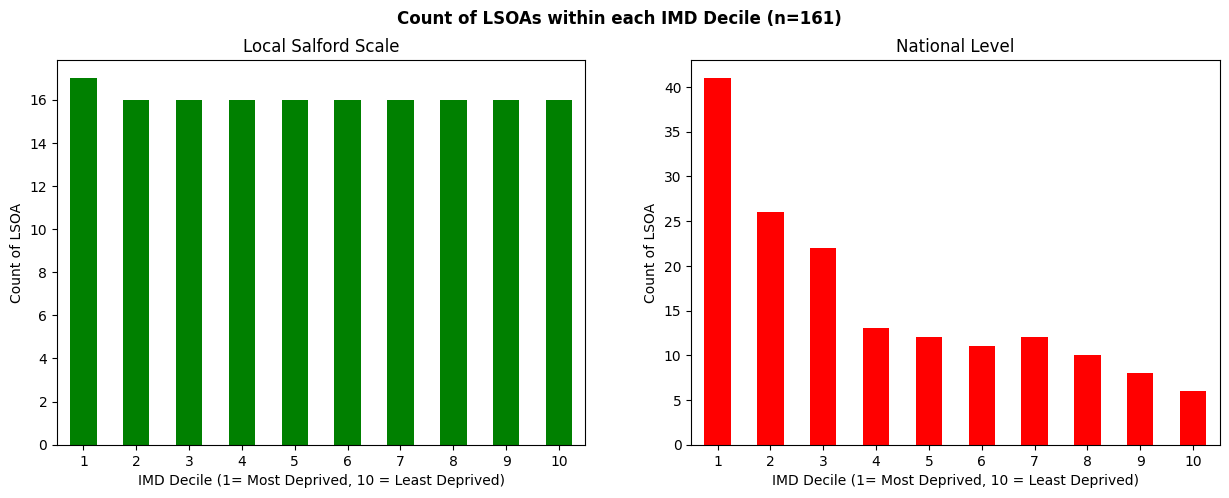

In [87]:
# Visualise the different distribution of LSOAs with categorisation methods. ##

Fig, ax = plt.subplots(1, 2, figsize=(15, 5))

Salford_IMD.groupby("Salford_IMDDecile").size().plot(ax=ax[0],kind='bar', color='green')

ax[0].set_title("Local Salford Scale")
ax[0].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[0].set_ylabel("Count of LSOA")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

Salford_IMD.groupby("IMDDecile").size().plot(ax=ax[1],kind='bar', color='red')

ax[1].set_title("National Level")
ax[1].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[1].set_ylabel("Count of LSOA")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

Fig.suptitle("Count of LSOAs within each IMD Decile (n=161)", fontweight='bold')

plt.show()

In [88]:
# Make a list of LSOA within Greater Manchester

SalfordLSOA21CD= Salford_IMD['LSOA21CD'].unique() # Make a list without duplicate s
SalfordLSOA = pd.DataFrame(SalfordLSOA21CD, columns=["LSOA21CD"])

SalfordLSOA.shape # Good to have a figure to check of number of LSOA to expect (161)

(161, 1)

**Defibrillator Locations**

The subset was converted to a GeoDataFrame, using shapely to convert the latitude and longitude to point geometry.




In [89]:
GreaterManchester_Defibs.columns = GreaterManchester_Defibs.columns.str.upper() # Format upper case
GreaterManchester_Defibs = GreaterManchester_Defibs.rename(columns={ #rename columns for consistency
    "LSOA21": "LSOA21CD",
    "LSOA21NM": "LSOA21NM",
    "LADNM": "LAD24NM"
})

#Drop columns not needed
GreaterManchester_Defibs=GreaterManchester_Defibs.drop(columns=["LOCATION_NAME","ADDRESS_LINE1", "ADDRESS_LINE2", "ADDRESS_LINE3", "ADDRESS_CITY", "ADDRESS_COUNTY", "COUNTRY", "COUNTY", "LSOA21NM"], axis=1)

#Filter Defib to only those in LSOA's in the list of 161 LSOAs in Salford
Salford_Defibs  = GreaterManchester_Defibs[GreaterManchester_Defibs["LSOA21CD"].isin(SalfordLSOA["LSOA21CD"])]


# Create geometry for defib locations from  lat and long in CSV using shapely

from shapely import Point
geometry_col =[Point(xy) for xy in zip(Salford_Defibs['LONG'], Salford_Defibs['LAT'])]

# Convert to geojson file and export to add to github

Salford_Defibs = gpd.GeoDataFrame(Salford_Defibs, geometry=geometry_col, crs=4326)
#Ensure all datasets are in same CRS (British National Grid 27700)
Salford_Defibs = Salford_Defibs.to_crs("EPSG:27700")


##Salford_Defibs.to_file('/content/drive/MyDrive/GEOG5003/Salford_Defibs.geojson', driver='GeoJSON')
Salford_Defibs.shape


(325, 9)

**Postcode Centroid data**



In [90]:
Salford_postcodes = Salford_postcodes.loc[:, ["LSOA21CD", "geometry", "PCD7"]] # select columns want to keep and create dataframe
Salford_postcodes.shape # Good to have a figure to check of number of LSOA to expect (12544)

(12544, 3)

**LSOA Polygons**





In [91]:
SalfordLSOA = GreaterManchester_LSOA[GreaterManchester_LSOA["LSOA21CD"].isin(SalfordLSOA["LSOA21CD"])]
SalfordLSOA.shape # Good to have a figure to check of number of LSOA to expect (161)

(161, 9)

# **Pre-processing**

All spatial data was converted to the British National Grid coordinate system (ESPG: 27700), to enable spatial joins and overlays. A table Join attributed the deprivation values to each LSOA and postcode.

Based on the assumption of walking at 3mph, a person could travel 400m in 5 minutes. Therefore, to be within 3-5 minutes suggested by Perkins et al (2015) defibrillation to improve survival rates you must be within 200m of an AED to make a return journey of 400m within 5 minutes. A buffer was generated around the AEDs and dissolved to a single polygon.

Using nearest spatial join, the shortest distance between each postcode and an AED was calculated. A spatial join identified which centroids intersect the 200m buffer populating a Boolean value of ‘covered’ or ‘not covered’ and the percentage coverage calculated per LSOA. Derived values were aggregated at LSOA and decile level and merged into the Joined data frame.

In [92]:
#Table Join - Deprivation values to LSOA

Joined_data = SalfordLSOA.merge(Salford_IMD, on='LSOA21CD', how='right', suffixes=('_left', '_right'))
Joined_data = Joined_data.drop(columns=["LSOA21NMW", "GlobalID"])

Joined_data.shape # Good to have a figure to check of number of LSOA to expect (161)


(161, 11)

In [93]:
# Convert all spatial df to British national grid (27700)

Salford_postcodes= Salford_postcodes.to_crs("EPSG:27700")
Joined_data = Joined_data.to_crs("EPSG:27700")
Salford_Defibs = Salford_Defibs.to_crs("EPSG:27700")

print("Postcodes:", Salford_postcodes.crs)
print("Joined Data:", Joined_data.crs)
print("Defibs:", Salford_Defibs.crs)

Postcodes: EPSG:27700
Joined Data: EPSG:27700
Defibs: EPSG:27700


In [94]:
# Calculate Distance from each postcode centroid to their nearest Defibrillator using nearest spatial join.

Salford_Defibs_unique = Salford_Defibs.drop_duplicates(subset=["geometry"]) # there were more than one for each post code, likely due to multiple defibs in one location or exact same distances
Salford_Defibs_unique = Salford_Defibs_unique.drop(columns=["LSOA21CD"])     # keep only LSOA details of the postcode centroid as it is access from there.
Postcode_Defib_Distances = Salford_postcodes.sjoin_nearest(Salford_Defibs_unique, how="left", distance_col="Distance") # nearest spatial join - distance_col calculats length between nearest joining point. (can be joint to multiple)
Postcode_Defib_Distances = Postcode_Defib_Distances.drop(columns=["index_right"])


In [95]:
# Merge Deprivation values per postcode based on value for LSOA it belongs

Postcode_Defib_Distances = Postcode_Defib_Distances.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right'))
Postcode_Defib_Distances.head()

,LSOA21CD,geometry,PCD7,UNIQUE_IDENTIFIER,ADDRESS_POST_CODE,LAD24NM,DEFIBRILLATORS_AVAILABILITY,DEFIBRILLATORS_ACCESS_TYPE,LAT,LONG,Distance,IMDRank,IMDDecile,Salford_IMDRank,Salford_IMDDecile
0,E01033991,POINT (381487.076 398313.886),M5 2PA,597A8DB2-A064-406A-8720-B0AB00FA8CAC,M5 4HH,Salford,24/7 Access,Public,53.481900,-2.280820,80.317447,8057,3,79,5
1,E01005650,POINT (383174.18 401442.777),M7 4QR,6D9B73C0-7A7F-4EB1-AFE1-AFFF00F2221B,M7 4FF,Salford,Varied Access,Public,53.508952,-2.261748,438.636610,2901,1,34,3
2,E01033982,POINT (379726.053 399011.91),M5 5JD,8578AE5F-914D-4133-B4E1-B435007EB14A,M6 5GZ,Salford,24/7 Access,Restricted,53.483600,-2.302390,524.538692,4911,2,56,4
3,E01005664,POINT (371705.144 404444.839),M38 9ST,38E02FB1-864C-4D52-B95F-B08800E1D31A,M38 9RB,Salford,Varied Access,Restricted,53.533450,-2.427580,276.103837,1007,1,15,1
4,E01005661,POINT (371824.132 403729.853),M38 0EJ,19C14E4F-087E-4CBF-B6D9-B475009E0F80,M28 0AY,Salford,24/7 Access,Public,53.530100,-2.423960,183.831059,3324,1,41,3


In [96]:
##Create 200m buffer around defibs ##

Defib_walking_buffer = Salford_Defibs.copy() # make a copy of defib df
Defib_walking_buffer['geometry'] = Defib_walking_buffer.buffer(distance=200) # use a buffer of distance 200m as to create the geometry
Defib_walking_buffer= Defib_walking_buffer.dissolve() # previous step created a buffer round each defib, this dissolves into one buffer polygon
Defib_walking_buffer=Defib_walking_buffer.drop(columns=['UNIQUE_IDENTIFIER', 'LAD24NM', 'LSOA21CD', 'DEFIBRILLATORS_AVAILABILITY', 'DEFIBRILLATORS_ACCESS_TYPE','LAT','LONG', 'ADDRESS_POST_CODE'])


Salford_outline = Joined_data.dissolve(method='coverage') # quicker for non ovelapping polygons
Salford_outline = Salford_outline.drop(columns=['LSOA21CD', 'LSOA21NM', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'Salford_IMDRank', 'Salford_IMDDecile'])

Defib_walking_buffer = Defib_walking_buffer.clip(Salford_outline) # clip to only include areas within the salford local authority boundary
Defib_walking_buffer # check one row with just geometry

,geometry
0,"MULTIPOLYGON (((370814.878 391507.558, 370799...."


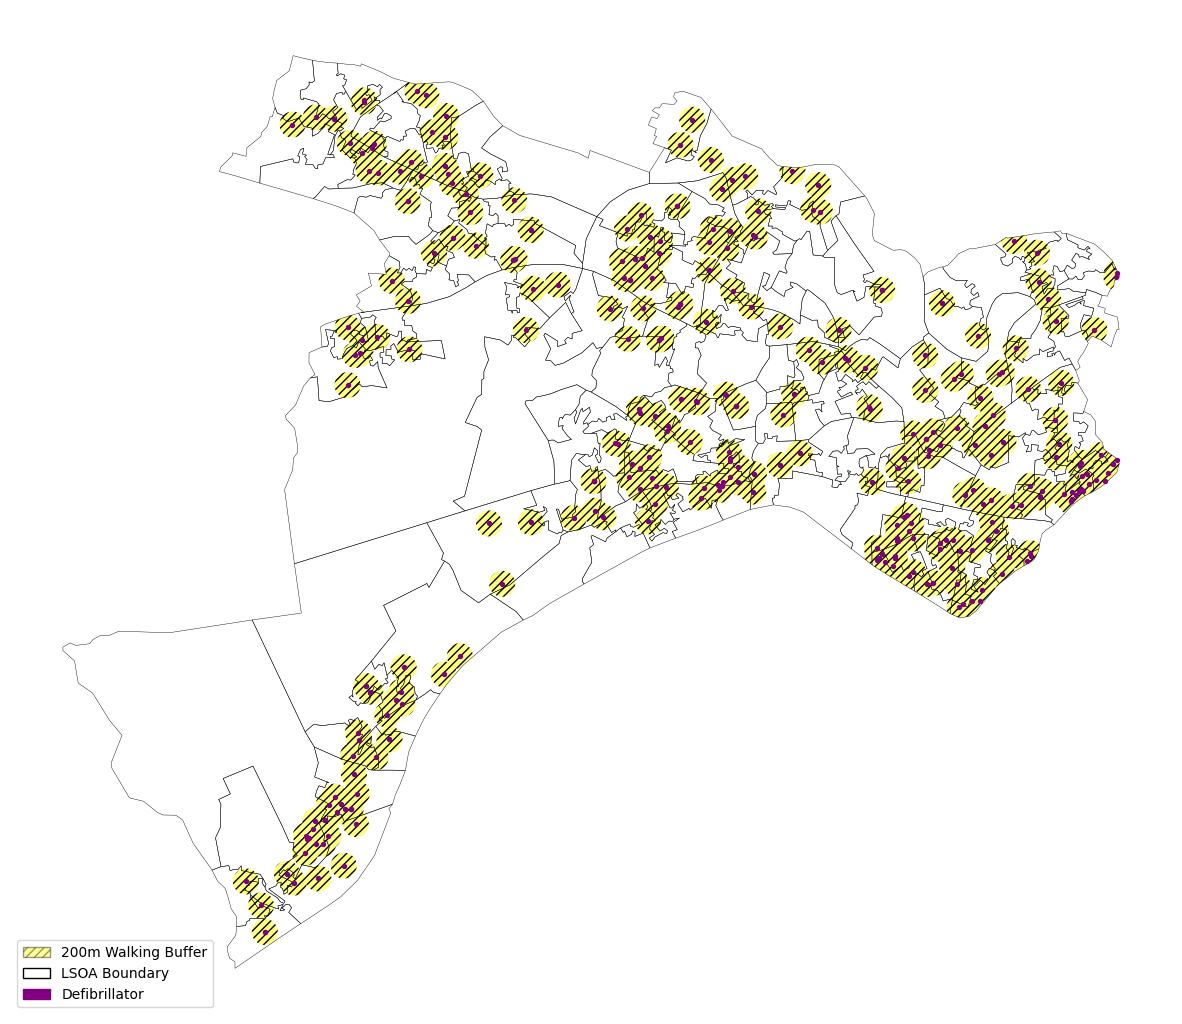

In [97]:
# plot map of 200m buffer

import matplotlib.patches as Patch # to create legend

Fig, ax = plt.subplots(1, figsize=(15, 15))

Defib_walking_buffer.plot(ax=ax, color='yellow', alpha=0.5, hatch='////', legend=True) # plot buffer as yellow hatched with some transparency
SalfordLSOA.plot(ax=ax, facecolor='None', edgecolor='black', linewidth=0.3) # plot LSOA outlines in black
Salford_Defibs.plot(ax=ax, color='purple', markersize=8, legend=True) # plot defib locations with purple markers

#Create legend as geopandas only creates one if there is a column specificed for the fill.
# Prompt: How can I create my own legend to visualise the colouring of my layers when it is not a choropleth using matplotlib and patches?
legend_elements = [
    Patch.Patch(facecolor='yellow', edgecolor='black', alpha=0.4, hatch='////', label='200m Walking Buffer'),
    Patch.Patch(facecolor='none', edgecolor='black', label='LSOA Boundary'),
    Patch.Patch(facecolor='purple', edgecolor='purple', label='Defibrillator')
]

ax.legend(handles=legend_elements, loc='lower left') # adjust location of legend


ax.set_axis_off() # remove axis just see map

# show the map
plt.show()

In [98]:
## Spatial Join to join identify postcode centroids within 200m buffer ##

Postcode_Defib_Distances = gpd.sjoin(Postcode_Defib_Distances, Defib_walking_buffer, how='left', predicate='intersects') # Spatial join with postcode and buffer dataframes

#Create a column which populated with True is centroid is within defib buffer and False if not inside buffer
Postcode_Defib_Distances["covered"]= Postcode_Defib_Distances["index_right"].notna() # where index_right was NaN, means it does not intersect with the buffer, this populated false in covered column, where inde-right is 0, populates true

Postcode_Defib_Distances.head()


,LSOA21CD,geometry,PCD7,UNIQUE_IDENTIFIER,ADDRESS_POST_CODE,LAD24NM,DEFIBRILLATORS_AVAILABILITY,DEFIBRILLATORS_ACCESS_TYPE,LAT,LONG,Distance,IMDRank,IMDDecile,Salford_IMDRank,Salford_IMDDecile,index_right,covered
0,E01033991,POINT (381487.076 398313.886),M5 2PA,597A8DB2-A064-406A-8720-B0AB00FA8CAC,M5 4HH,Salford,24/7 Access,Public,53.481900,-2.280820,80.317447,8057,3,79,5,0.0,True
1,E01005650,POINT (383174.18 401442.777),M7 4QR,6D9B73C0-7A7F-4EB1-AFE1-AFFF00F2221B,M7 4FF,Salford,Varied Access,Public,53.508952,-2.261748,438.636610,2901,1,34,3,NaN,False
2,E01033982,POINT (379726.053 399011.91),M5 5JD,8578AE5F-914D-4133-B4E1-B435007EB14A,M6 5GZ,Salford,24/7 Access,Restricted,53.483600,-2.302390,524.538692,4911,2,56,4,NaN,False
3,E01005664,POINT (371705.144 404444.839),M38 9ST,38E02FB1-864C-4D52-B95F-B08800E1D31A,M38 9RB,Salford,Varied Access,Restricted,53.533450,-2.427580,276.103837,1007,1,15,1,NaN,False
4,E01005661,POINT (371824.132 403729.853),M38 0EJ,19C14E4F-087E-4CBF-B6D9-B475009E0F80,M28 0AY,Salford,24/7 Access,Public,53.530100,-2.423960,183.831059,3324,1,41,3,0.0,True


In [99]:
## Aggregate per Decile ##

# 1.	Group by LSOA or Decile
# 2.	Calculate the count of postcodes 'covered' and 'not covered' within the 200m buffer of defibrillator points.
decile_coverage_agg = Postcode_Defib_Distances.groupby(["Salford_IMDDecile", "covered"]).size().reset_index(name='count')

# 3.	Calculate total number of postcodes per LSOA or Decile
decile_coverage_agg["decile_total_postcodes"] = decile_coverage_agg.groupby("Salford_IMDDecile")["count"].transform("sum") # maintain the original indexes so that it doesnt just assign the values to the first 10 rows

# 4.	Calculate percentage covered and not covered
decile_coverage_agg["percentage_covered"] = decile_coverage_agg["count"] / decile_coverage_agg["decile_total_postcodes"] * 100 # calulate percentage of postcodes within IMD decile within 200m distance of defib


decile_coverage_agg # check as expect to see


,Salford_IMDDecile,covered,count,decile_total_postcodes,percentage_covered
0,1,False,867,1376,63.008721
1,1,True,509,1376,36.991279
2,2,False,686,1136,60.387324
3,2,True,450,1136,39.612676
4,3,False,642,1257,51.073986
5,3,True,615,1257,48.926014
6,4,False,618,1283,48.168355
7,4,True,665,1283,51.831645
8,5,False,596,1789,33.314701
9,5,True,1193,1789,66.685299


In [100]:
# 5.	Pivot dataframe tables to be in wide format to create one row for each LSOA or IMD decile with a column for covered and not covered percentage.

decile_coverage_agg_wide = decile_coverage_agg.pivot(
    index="Salford_IMDDecile", # Row for each decile
    columns="covered",   # converts values from covered (True / False) into the column headings
    values="percentage_covered" # Populates columns with percentage _covered calculated for True and False per decile
)

# Rename columns from boolean output to Covered and Not Covered
decile_coverage_agg_wide = decile_coverage_agg_wide.rename(columns={
    True: "Covered",
    False: "Not Covered"
})

decile_coverage_agg_wide = decile_coverage_agg_wide.reset_index()
decile_coverage_agg_wide = decile_coverage_agg_wide[["Salford_IMDDecile", "Covered", "Not Covered"]]# Create df with three columns specified.
decile_coverage_agg_wide[["Covered", "Not Covered"]] = decile_coverage_agg_wide[["Covered", "Not Covered"]].fillna(0) # replace null values with 0 so that total coverage equals 100%
decile_coverage_agg_wide


covered,Salford_IMDDecile,Covered,Not Covered
0,1,36.991279,63.008721
1,2,39.612676,60.387324
2,3,48.926014,51.073986
3,4,51.831645,48.168355
4,5,66.685299,33.314701
5,6,43.898305,56.101695
6,7,57.851759,42.148241
7,8,56.481481,43.518519
8,9,51.740696,48.259304
9,10,33.836590,66.163410


In [101]:
# Aggregate per LSOA

# 1.	Group by LSOA
# 2.	Calculate the count of postcodes 'covered' and 'not covered' within the 200m buffer of defibrillator points.
LSOA_coverage_agg = Postcode_Defib_Distances.groupby(["LSOA21CD", "covered"]).size().reset_index(name='count')

# 3.	Calculate total number of postcodes per LSOA or Decile
LSOA_coverage_agg["LSOA_total_postcodes"] = LSOA_coverage_agg.groupby("LSOA21CD")["count"].transform("sum") # maintain the original indexes so that it doesnt just assign the values to the first 10 rows
# 4.	Calculate percentage covered and not covered
LSOA_coverage_agg["percentage_covered"] = LSOA_coverage_agg["count"] / LSOA_coverage_agg["LSOA_total_postcodes"] * 100 # calculate percentage of postcodes within each LSOA within 200m distance of defib
LSOA_coverage_agg.sort_values(by="percentage_covered")

,LSOA21CD,covered,count,LSOA_total_postcodes,percentage_covered
245,E01005738,True,1,115,0.869565
89,E01005648,True,1,108,0.925926
215,E01005721,True,1,66,1.515152
169,E01005696,True,2,86,2.325581
183,E01005703,True,2,70,2.857143
...,...,...,...,...,...
222,E01005726,False,33,33,100.000000
279,E01033982,False,93,93,100.000000
43,E01005625,False,29,29,100.000000
290,E01033988,True,69,69,100.000000


In [102]:
# 5.	Pivot dataframe tables to be in wide format to create one row for each LSOA or IMD decile with a column for covered and not covered percentage.
LSOA_coverage_agg_wide = LSOA_coverage_agg.pivot(
    index="LSOA21CD", # Row for each LSOA code
    columns="covered", # converts values from covered (True / False) into the column headings
    values="percentage_covered" # Populates columns with percentage _covered calculated for True and False per LSOA
)
# Rename columns from boolean output to Covered and Not Covered
LSOA_coverage_agg_wide = LSOA_coverage_agg_wide.rename(columns={
    True: "Covered",
    False: "Not Covered"
})


LSOA_coverage_agg_wide = LSOA_coverage_agg_wide.reset_index()
LSOA_coverage_agg_wide = LSOA_coverage_agg_wide[["LSOA21CD", "Covered", "Not Covered"]] # Create df with three columns specified.
LSOA_coverage_agg_wide[["Covered", "Not Covered"]] = LSOA_coverage_agg_wide[["Covered", "Not Covered"]].fillna(0) # replace null values with 0 so that total coverage equals 100%


LSOA_coverage_agg_wide.sort_values(by="Covered")

covered,LSOA21CD,Covered,Not Covered
5,E01005604,0.0,100.0
22,E01005625,0.0,100.0
113,E01005726,0.0,100.0
112,E01005725,0.0,100.0
109,E01005722,0.0,100.0
...,...,...,...
132,E01032909,100.0,0.0
149,E01033988,100.0,0.0
151,E01033990,100.0,0.0
155,E01033994,100.0,0.0


In [103]:
# Calculate average distances to defib per LSOA

Average_Distances= Postcode_Defib_Distances.groupby("LSOA21CD")["Distance"].mean().reset_index() # Calculate mean distance between postcode centroid and defib for each LSOA
Average_Distances = Average_Distances.rename(columns={"Distance":"Average_Distance"}) # Rename column to average

#6.	Merge LSOA table with LSOA polygons to create GeoDataFrame which can be plotted on a choropleth map.
Joined_data = Joined_data.merge(Average_Distances, on='LSOA21CD', how='left', suffixes=('_left', '_right')) # Merge the average distances per LSOA into Joined Data
Joined_data = Joined_data.merge(LSOA_coverage_agg_wide, on='LSOA21CD', how='left', suffixes=('_left', '_right')) # Merge coverage percentages into Joined Data
Joined_data["Coverage_Check"] = Joined_data["Covered"] + Joined_data["Not Covered"]   # Add covered and not covered percentage to check total is 100% and no errors/null values remaining
Joined_data.head()


,LSOA21CD,LSOA21NM,BNG_E,BNG_N,LAT,LONG,geometry,IMDRank,IMDDecile,Salford_IMDRank,Salford_IMDDecile,Average_Distance,Covered,Not Covered,Coverage_Check
0,E01005664,Salford 001D,371588,404645,53.5377,-2.43016,"POLYGON ((371788.055 404849.746, 371799.999 40...",1007,1,15,1,408.932952,12.121212,87.878788,100.0
1,E01005659,Salford 001A,371184,404376,53.5353,-2.43623,"POLYGON ((371450.121 404752.048, 371408.864 40...",2044,1,27,2,292.879777,32.098765,67.901235,100.0
2,E01005662,Salford 004B,371094,403764,53.5298,-2.43754,"POLYGON ((370963.908 404180.515, 371037.341 40...",467,1,9,1,383.565986,11.428571,88.571429,100.0
3,E01005660,Salford 001B,371969,404133,53.5331,-2.42437,"POLYGON ((372352.125 404701, 372420.992 404663...",130,1,2,1,171.287983,57.446809,42.553191,100.0
4,E01005703,Salford 002A,372696,404210,53.5338,-2.41341,"POLYGON ((373029.409 404323.061, 373043.629 40...",687,1,14,1,366.325115,2.857143,97.142857,100.0


#**Statistical Analysis**

The descriptive statistics were inspected to identify patterns and potential relationships between deprivation and access to AEDs.

The distribution of distances calculated between postcode centroids and AEDs presented a highly skewed distribution with the mean distance of 240m, interquartile range from 117-314m with values tailing off to a maximum of 4543m. This distribution is visible in the box plot and histograms below.

 This was compared with the distribution of the log of the distances, to identify any trends without the skew, showing a more normal distribution with one large outlier.

Spearman’s rank test was carried out on Salford IMD rank against Average Distance, and Coverage percentage. The p values of both were considered statistically non-significant. The spearman’s coefficients of -0.07 and 0.04 do not show any covariance between the variables. Increased deprivation does not associate with increased or decreased distance accessibility to AEDs.



In [104]:
Joined_data.describe()

,BNG_E,BNG_N,LAT,LONG,IMDRank,IMDDecile,Salford_IMDRank,Salford_IMDDecile,Average_Distance,Covered,Not Covered,Coverage_Check
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,1.610000e+02
mean,377539.968944,399978.434783,53.496027,-2.340024,11492.422360,3.931677,81.000000,5.472050,258.044033,43.433773,56.566227,1.000000e+02
std,3809.011396,2574.271722,0.023138,0.057414,9415.564046,2.777418,46.620811,2.894093,130.198997,28.263066,28.263066,3.552714e-15
min,369632.000000,391664.000000,53.421000,-2.458710,28.000000,1.000000,1.000000,1.000000,45.194041,0.000000,0.000000,1.000000e+02
25%,374274.000000,398612.000000,53.484000,-2.389060,3324.000000,1.000000,41.000000,3.000000,174.632738,21.333333,36.585366,1.000000e+02
50%,377765.000000,399928.000000,53.495700,-2.336550,8695.000000,3.000000,81.000000,5.000000,232.573794,39.682540,60.317460,1.000000e+02
75%,380608.000000,401833.000000,53.512700,-2.293650,18439.000000,6.000000,121.000000,8.000000,302.003272,63.414634,78.666667,1.000000e+02
max,383591.000000,404669.000000,53.537900,-2.248750,33005.000000,10.000000,161.000000,10.000000,1026.327721,100.000000,100.000000,1.000000e+02


In [105]:
Postcode_Defib_Distances.describe()

,LAT,LONG,Distance,IMDRank,IMDDecile,Salford_IMDRank,Salford_IMDDecile,index_right
count,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,12544.000000,6232.0
mean,53.496907,-2.334969,240.310448,10564.420121,3.664142,77.866789,5.281649,0.0
std,0.022888,0.057675,197.611170,8743.903740,2.581156,44.017013,2.756855,0.0
min,53.420937,-2.446980,0.000251,28.000000,1.000000,1.000000,1.000000,0.0
25%,53.482979,-2.382848,117.091076,3324.000000,1.000000,41.000000,3.000000,0.0
50%,53.500456,-2.335542,201.449826,8057.000000,3.000000,79.000000,5.000000,0.0
75%,53.512772,-2.280820,314.678857,15187.750000,5.000000,110.250000,7.000000,0.0
max,53.537321,-2.245680,4543.233905,33005.000000,10.000000,161.000000,10.000000,0.0


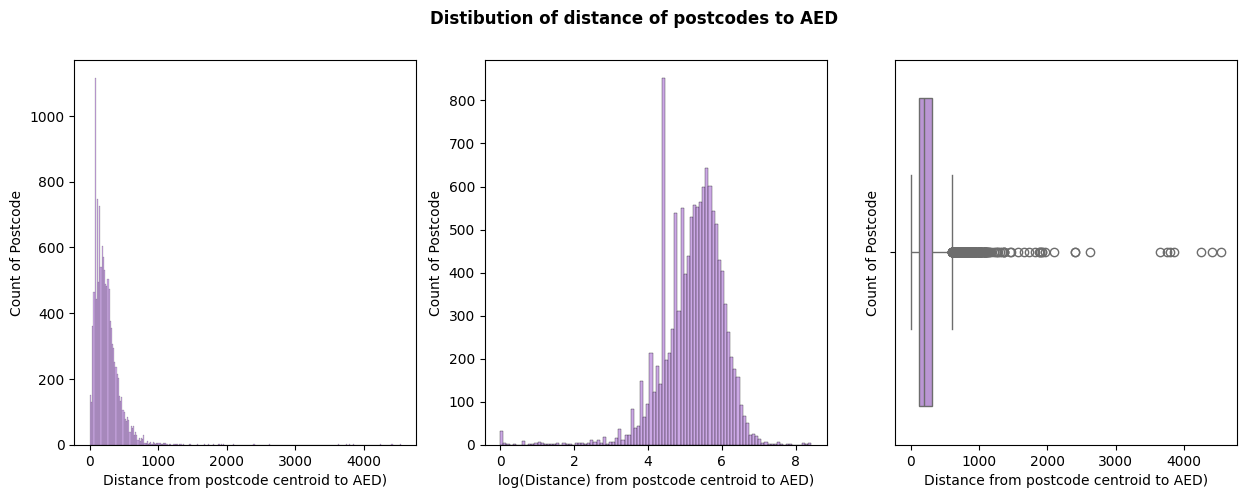

In [106]:
Postcode_Defib_Distances["Distance_log"] = np.log1p(Postcode_Defib_Distances["Distance"])
Fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(Postcode_Defib_Distances, x="Distance", ax=ax[0], color='#bc8cde')

ax[0].set_xlabel("Distance from postcode centroid to AED)")
ax[0].set_ylabel("Count of Postcode")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

sns.histplot(Postcode_Defib_Distances, x="Distance_log", ax=ax[1], color='#bc8cde')

ax[1].set_xlabel("log(Distance) from postcode centroid to AED)")
ax[1].set_ylabel("Count of Postcode")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

sns.boxplot(data=Postcode_Defib_Distances, x="Distance", ax=ax[2], color='#bc8cde')

ax[2].set_xlabel("Distance from postcode centroid to AED)")
ax[2].set_ylabel("Count of Postcode")
ax[2].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

Fig.suptitle("Distibution of distance of postcodes to AED ", fontweight='bold')

plt.show()

In [107]:
## Spearmans rank correlation test

from scipy.stats import spearmanr

corr, p = spearmanr(
    Joined_data["Average_Distance"], # variable 1
    Joined_data["Salford_IMDRank"]   # variable 2
)

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: -0.07409420289855073
p-value: 0.35024752168534345


In [108]:
corr, p = spearmanr(
    Postcode_Defib_Distances["covered"].astype(int), #variable 1
    Postcode_Defib_Distances["Salford_IMDDecile"]    #variable 2
)

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.04060512284583767
p-value: 5.385110880988368e-06


# **Exploration Data Analysis**

A pair plot was used to assess potential relationships across the grouped data along with other visual plots such as scatters. However, bar charts variations were the most appropriate method to visualise the categorised data. Stacking was used to effectively visualise the percentage coverage, which provided a better comparison between the proportional differences. This is also a more appropriate plot choice as using raw counts would not be fair as not all LSOAs have uniform postcode count.  

In [109]:
## Quick test of mean distances per IMD decile

Postcode_Defib_Distances.groupby("Salford_IMDDecile")["Distance"].mean() # group by decile and calculate mean distance

,Distance
Salford_IMDDecile,
1,262.210080
2,245.724451
3,252.816088
4,275.492916
5,183.809493
6,241.721342
7,221.545263
8,196.538917
9,217.954762


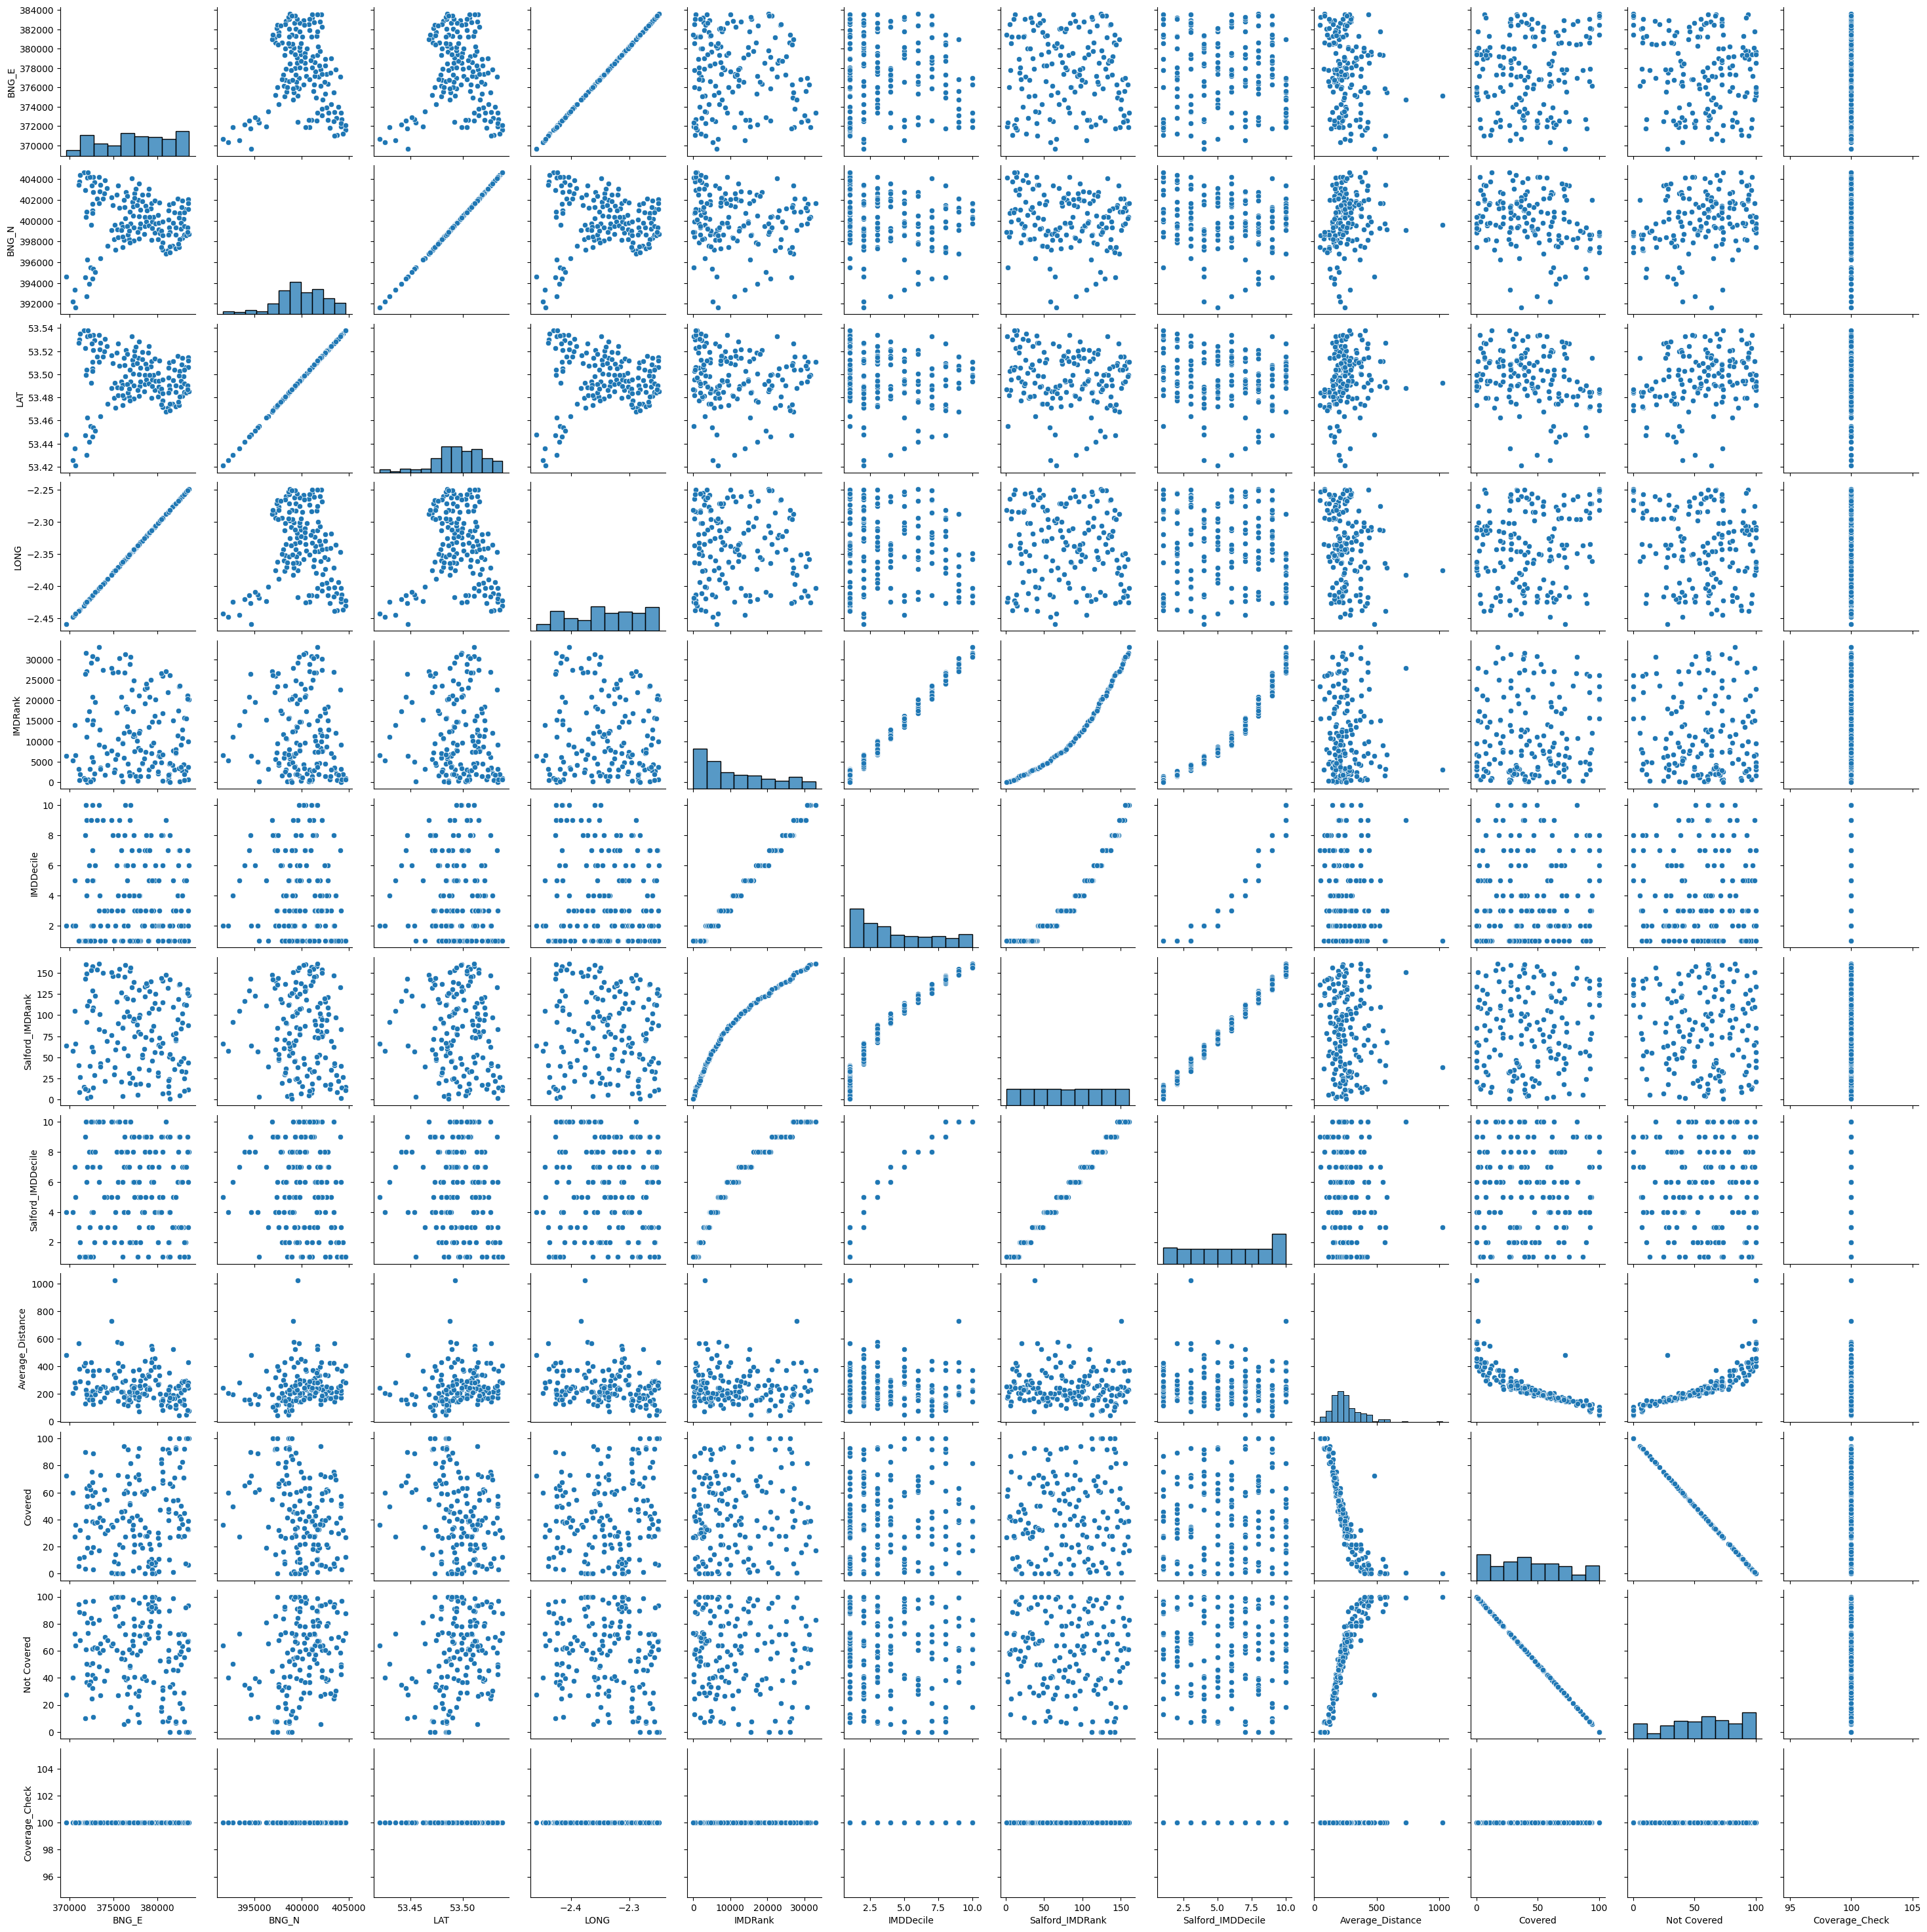

In [110]:
sns.pairplot(Joined_data)

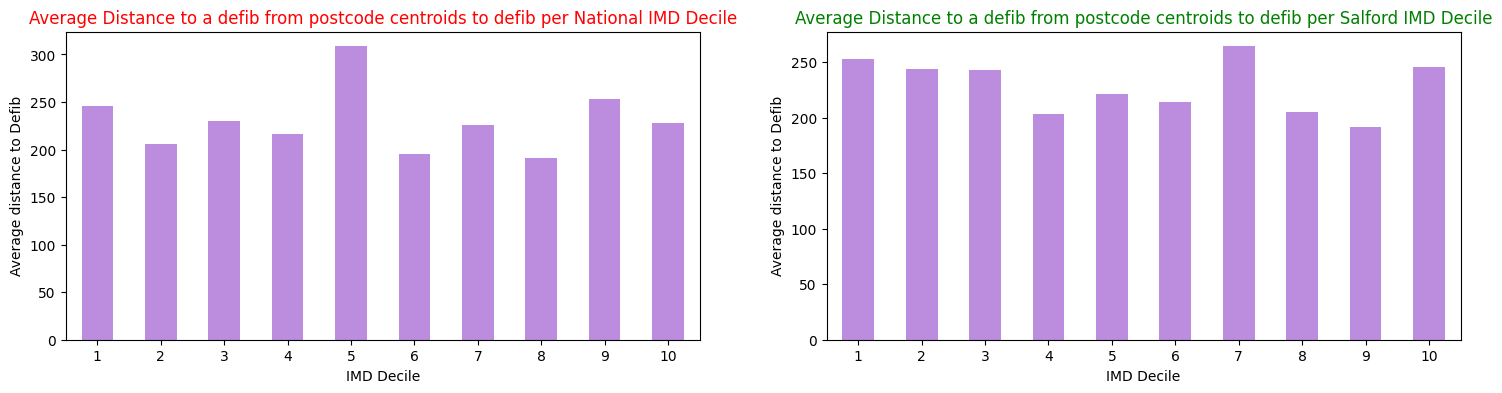

In [111]:
f,ax = plt.subplots (1,2, figsize=(18,4))

Joined_data.groupby("IMDDecile")["Average_Distance"].median().plot(ax=ax[0],kind="bar", color='#bc8cde')

ax[0].set_title("Average Distance to a defib from postcode centroids to defib per National IMD Decile", color='red')
ax[0].set_xlabel("IMD Decile")
ax[0].set_ylabel("Average distance to Defib")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

Joined_data.groupby("Salford_IMDDecile")["Average_Distance"].median().plot(ax=ax[1],kind="bar", color='#bc8cde')

ax[1].set_title("Average Distance to a defib from postcode centroids to defib per Salford IMD Decile", color='green')
ax[1].set_xlabel("IMD Decile")
ax[1].set_ylabel("Average distance to Defib")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal;

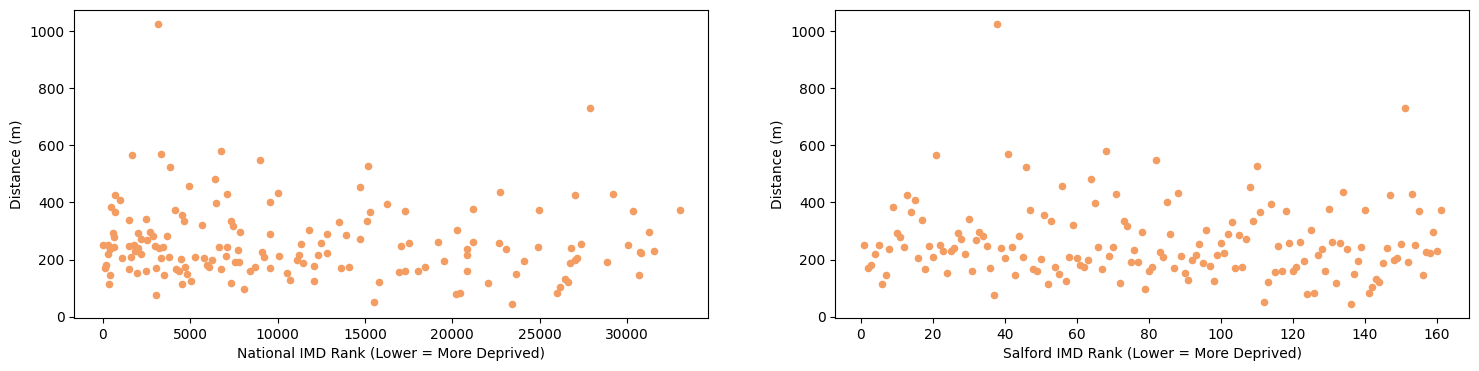

In [112]:
f,ax = plt.subplots (1,2, figsize=(18,4))

Joined_data.plot.scatter(ax=ax[0], x='IMDRank', y='Average_Distance', color="#f39d63")

ax[0].set_xlabel("National IMD Rank (Lower = More Deprived)")
ax[0].set_ylabel("Distance (m)")

Joined_data.plot.scatter(ax=ax[1], x='Salford_IMDRank', y='Average_Distance',color= "#f39d63")

ax[1].set_xlabel("Salford IMD Rank (Lower = More Deprived)")
ax[1].set_ylabel("Distance (m)");



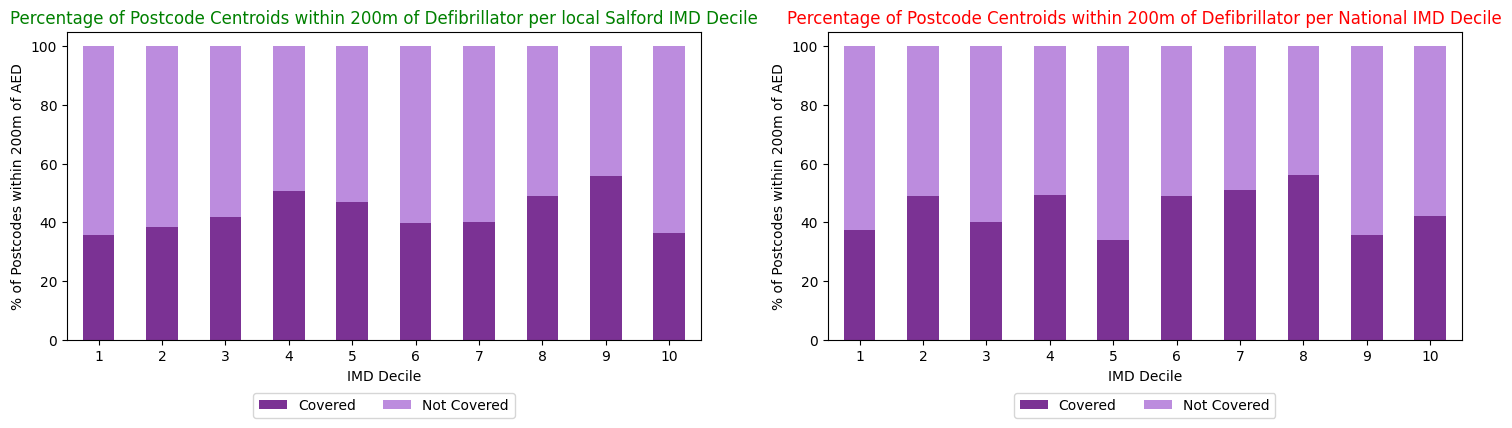

In [113]:
f,ax = plt.subplots (1,2, figsize=(18,4))

colors_availability = ["#7b3294","#bc8cde"]


Joined_data.groupby("Salford_IMDDecile")[["Covered", "Not Covered"]].mean().plot(ax=ax[0],kind="bar", stacked=True, color=colors_availability)

ax[0].set_title("Percentage of Postcode Centroids within 200m of Defibrillator per local Salford IMD Decile", color='green')
ax[0].set_xlabel("IMD Decile")
ax[0].set_ylabel("% of Postcodes within 200m of AED")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[0].legend(loc='upper center',bbox_to_anchor=(0.5, -0.15), ncol=2); #  move beneath plots and list horizontally.

Joined_data.groupby("IMDDecile")[["Covered", "Not Covered"]].mean().plot(ax=ax[1],kind="bar", stacked=True, color=colors_availability)

ax[1].set_title("Percentage of Postcode Centroids within 200m of Defibrillator per National IMD Decile", color='red')
ax[1].set_xlabel("IMD Decile")
ax[1].set_ylabel("% of Postcodes within 200m of AED")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[1].legend(loc='upper center',bbox_to_anchor=(0.5, -0.15), ncol=2); #  move beneath plots and list horizontally. ;

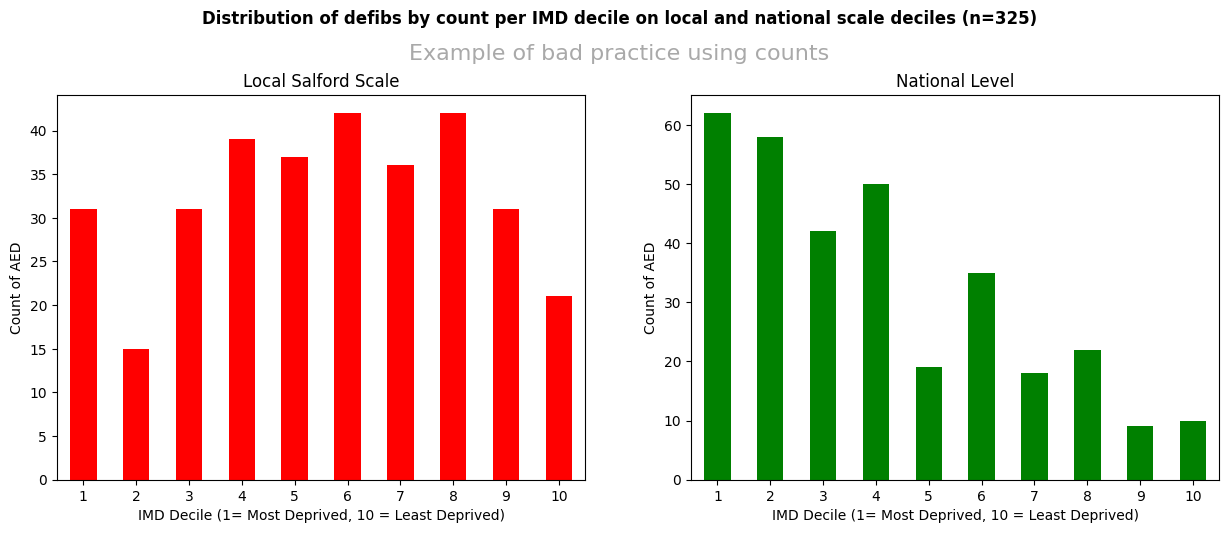

In [114]:
Fig, ax = plt.subplots(1, 2, figsize=(15, 5))

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby("Salford_IMDDecile").size().plot(ax=ax[0],kind="bar", color='red')

ax[0].set_title("Local Salford Scale")
ax[0].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[0].set_ylabel("Count of AED")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby("IMDDecile").size().plot(ax=ax[1],kind="bar", color='green')

ax[1].set_title("National Level")
ax[1].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[1].set_ylabel("Count of AED")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal

Fig.suptitle("Distribution of defibs by count per IMD decile on local and national scale deciles (n=325)", fontweight='bold', y=1.05)

Fig.text(0.5, 0.95, "Example of bad practice using counts", ha='center', fontsize=16, color='darkgray')

plt.show()

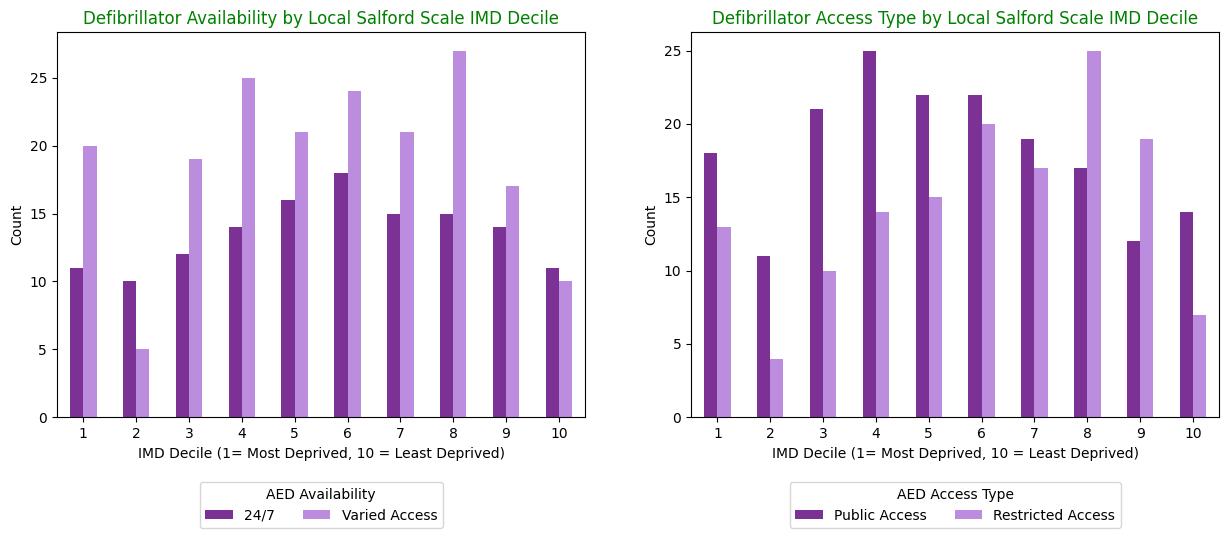

In [115]:
Fig, ax = plt.subplots(1, 2, figsize=(15, 5))

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby(["Salford_IMDDecile", "DEFIBRILLATORS_AVAILABILITY"]).size().unstack().plot(ax=ax[0],kind="bar", color=colors_availability)

ax[0].set_title("Defibrillator Availability by Local Salford Scale IMD Decile", color='green')
ax[0].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[0].legend(title="AED Availability",labels=["24/7", "Varied Access"], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2) # Improve legend lables, move beneath plots and list horizontally.

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby(["Salford_IMDDecile", "DEFIBRILLATORS_ACCESS_TYPE"]).size().unstack().plot(ax=ax[1],kind="bar", color=colors_availability)

ax[1].set_title("Defibrillator Access Type by Local Salford Scale IMD Decile", color='green')
ax[1].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[1].set_ylabel("Count")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[1].legend(title="AED Access Type",labels=["Public Access", "Restricted Access"],loc='upper center',bbox_to_anchor=(0.5, -0.15), ncol=2); # Improve legend lables, move beneath plots and list horizontally.

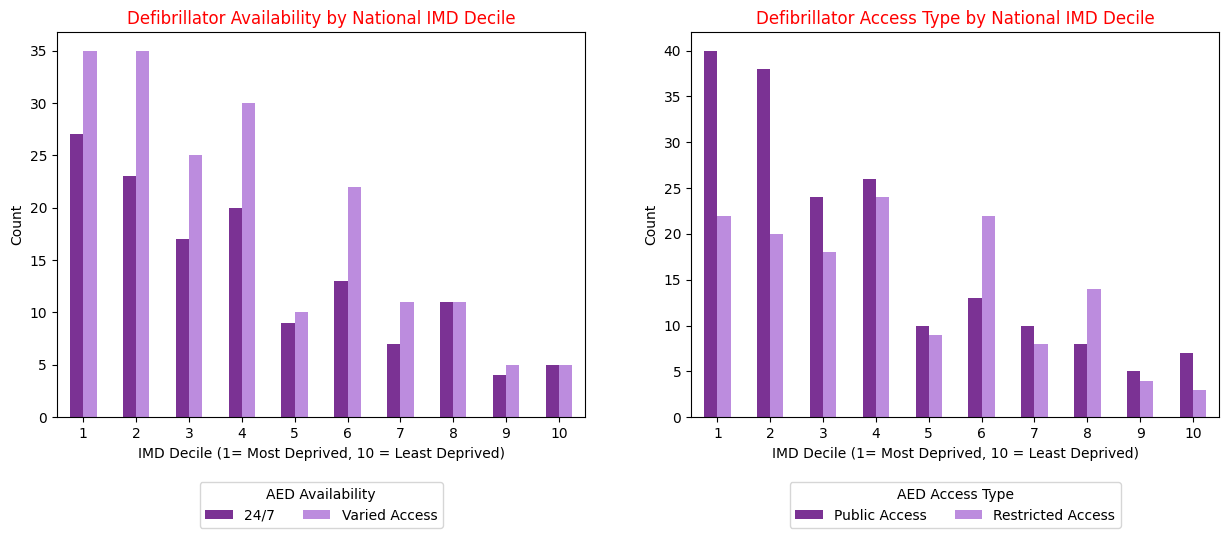

In [116]:

###### example why cannot use raw counts and with national as there is more LSOAs within the lower deciles
# which makes it look like theres more defibs within more deprived,
# however it is just that there is a higher proportion of more deprived areas in salford than lower

Fig, ax = plt.subplots(1, 2, figsize=(15, 5))

colors_availability = ["#7b3294","#bc8cde"]


Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby(["IMDDecile", "DEFIBRILLATORS_AVAILABILITY"]).size().unstack().plot(ax=ax[0],kind="bar", color=colors_availability)

ax[0].set_title("Defibrillator Availability by National IMD Decile", color='red')
ax[0].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[0].set_ylabel("Count")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[0].legend(title="AED Availability",labels=["24/7", "Varied Access"], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2) # Improve legend lables, move beneath plots and list horizontally.

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby(["IMDDecile", "DEFIBRILLATORS_ACCESS_TYPE"]).size().unstack().plot(ax=ax[1],kind="bar", color=colors_availability)

ax[1].set_title("Defibrillator Access Type by National IMD Decile", color='red')
ax[1].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[1].set_ylabel("Count")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[1].legend(title="AED Access Type",labels=["Public Access", "Restricted Access"],loc='upper center',bbox_to_anchor=(0.5, -0.15), ncol=2); # Improve legend lables, move beneath plots and list horizontally.

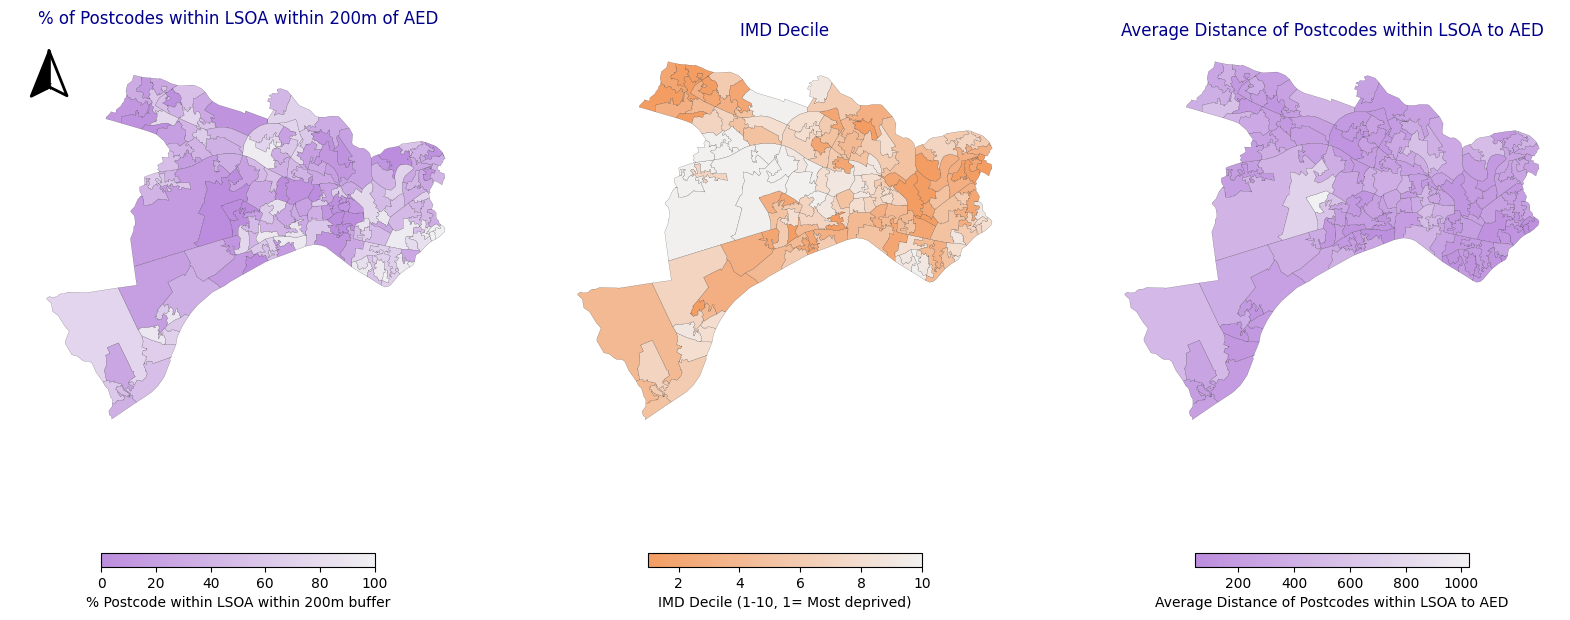

In [117]:
#Create choropleths for deprivation, coverage and average distance per LSOA

#Create colour palettes
purple_palette = sns.light_palette("#bc8cde", reverse=True, as_cmap=True) # accessibility = orange
orange_palette = sns.light_palette("#f39d63", reverse=True, as_cmap=True) # deprivation = orange

f,ax = plt.subplots (1,3, figsize=(20,10))

# AED Coverage #
Joined_data.plot(ax=ax[0], # , 0= 1st column
                 column ='Covered',
                 legend=True,  # include a legend
                 legend_kwds={'shrink': 0.6, 'label':'% Postcode within LSOA within 200m buffer', 'orientation':'horizontal'}, #change size of legend to 60% and and add legend label.
                 cmap=purple_palette, # map colour palatter defined above
                 edgecolor='black',
                 linewidth=0.1) # polygon outlines

# Deprivation Level #
Joined_data.plot(ax=ax[1], #  1= 2nd column
                 column ='Salford_IMDDecile',
                 legend=True,   # include a legend
                 legend_kwds={'shrink': 0.6, 'label':'IMD Decile (1-10, 1= Most deprived)', 'orientation':'horizontal'},#change size of legend to 60% and and add legend label
                 cmap=orange_palette,   # map colour palatter defined above
                 edgecolor='black',
                 linewidth=0.1)

# Average Distance #
Joined_data.plot(ax=ax[2], # 1= 3rd column
                 column ='Average_Distance',
                 legend=True,   # include a legend
                 legend_kwds={'shrink': 0.6, 'label':'Average Distance of Postcodes within LSOA to AED', 'orientation':'horizontal'}, #change size of legend to 60% and and add legend label
                 cmap=purple_palette, # map colour palatter defined above
                 edgecolor='black',
                 linewidth=0.1)


# Add a North arrow (https://github.com/pmdscully/geo_northarrow)

# Define plot to add to
axarrow = ax[0]
# Add north arrow
add_north_arrow(
    axarrow,scale=1, xlim_pos=0.05,ylim_pos=0.9,color="#000") # choose position within plot

##Subplot titles ##
ax[0].set_title('% of Postcodes within LSOA within 200m of AED', color='darkblue')
ax[1].set_title('IMD Decile', color='darkblue')
ax[2].set_title('Average Distance of Postcodes within LSOA to AED', color='darkblue')


## Make axis invisible
ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

# show figure
plt.show()

# **Results**

A consistent colour scheme has been used throughout. Purple denoting accessibility, with high saturation reflecting higher accessibility. Orange is deprivation with dark orange illustrating higher deprivation. The colours have been tested for impact on colour blindness.

The target audience is policymakers who influence decision making on funding and education around defibrillators.  


Text(0.5, 1.05, 'AED Availability and Access type with Socioeconomic Deprivation in Salford')

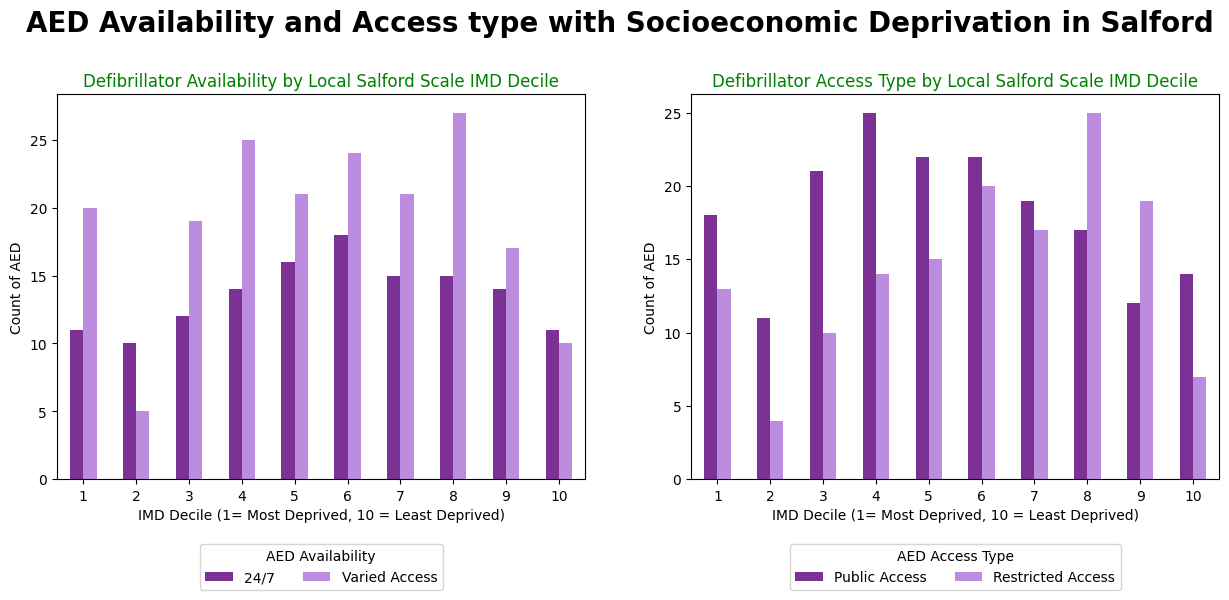

In [118]:
Fig, ax = plt.subplots(1, 2, figsize=(15, 5))

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby(["Salford_IMDDecile", "DEFIBRILLATORS_AVAILABILITY"]).size().unstack().plot(ax=ax[0],kind="bar", color=colors_availability)

ax[0].set_title("Defibrillator Availability by Local Salford Scale IMD Decile", color='green')
ax[0].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[0].set_ylabel("Count of AED")
ax[0].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[0].legend(title="AED Availability",labels=["24/7", "Varied Access"], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2) # Improve legend lables, move beneath plots and list horizontally.

Salford_Defibs.merge(Salford_IMD, on='LSOA21CD', how='left', suffixes=('_left', '_right')).groupby(["Salford_IMDDecile", "DEFIBRILLATORS_ACCESS_TYPE"]).size().unstack().plot(ax=ax[1],kind="bar", color=colors_availability)

ax[1].set_title("Defibrillator Access Type by Local Salford Scale IMD Decile", color='green')
ax[1].set_xlabel("IMD Decile (1= Most Deprived, 10 = Least Deprived)")
ax[1].set_ylabel("Count of AED")
ax[1].tick_params(axis='x', rotation=0) # rotate labels on x axis so horizontal
ax[1].legend(title="AED Access Type",labels=["Public Access", "Restricted Access"],loc='upper center',bbox_to_anchor=(0.5, -0.15), ncol=2); # Improve legend lables, move beneath plots and list horizontally.

Fig.suptitle("AED Availability and Access type with Socioeconomic Deprivation in Salford", fontsize=20, fontweight='bold', y=1.05) # Main title

Overlaying the variables (Deprivation and AED Access) using a bivariate choropleth map rather than a separate is a visual method of highlighting spatial relationships and correlations (Allen et al., 2025). It is easy to interpret areas of High Deprivation-Good Accessibility, Low-Deprivation-Good Accessibility, High-Deprivation-Low Accessibility and Low-Deprivation-Low Accessibility.

It provides targeted areas for policy makers of where need intervention to improve AED accessibility by the purple and red sections which denote low AED coverage.

The data has been generalised into a 2x2 matrix. Initially this was 3x3, however, nine colours are difficult to interpret.

Originally variables were assigned bins using a median split, however the ‘average distance from defibrillator’ was later split at 200m as used within the study to define distance accessibility.


/tmp/ipykernel_600/1765764740.py:37: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  Joined_data.plot(
/tmp/ipykernel_600/1765764740.py:124: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  Joined_data.plot(


''

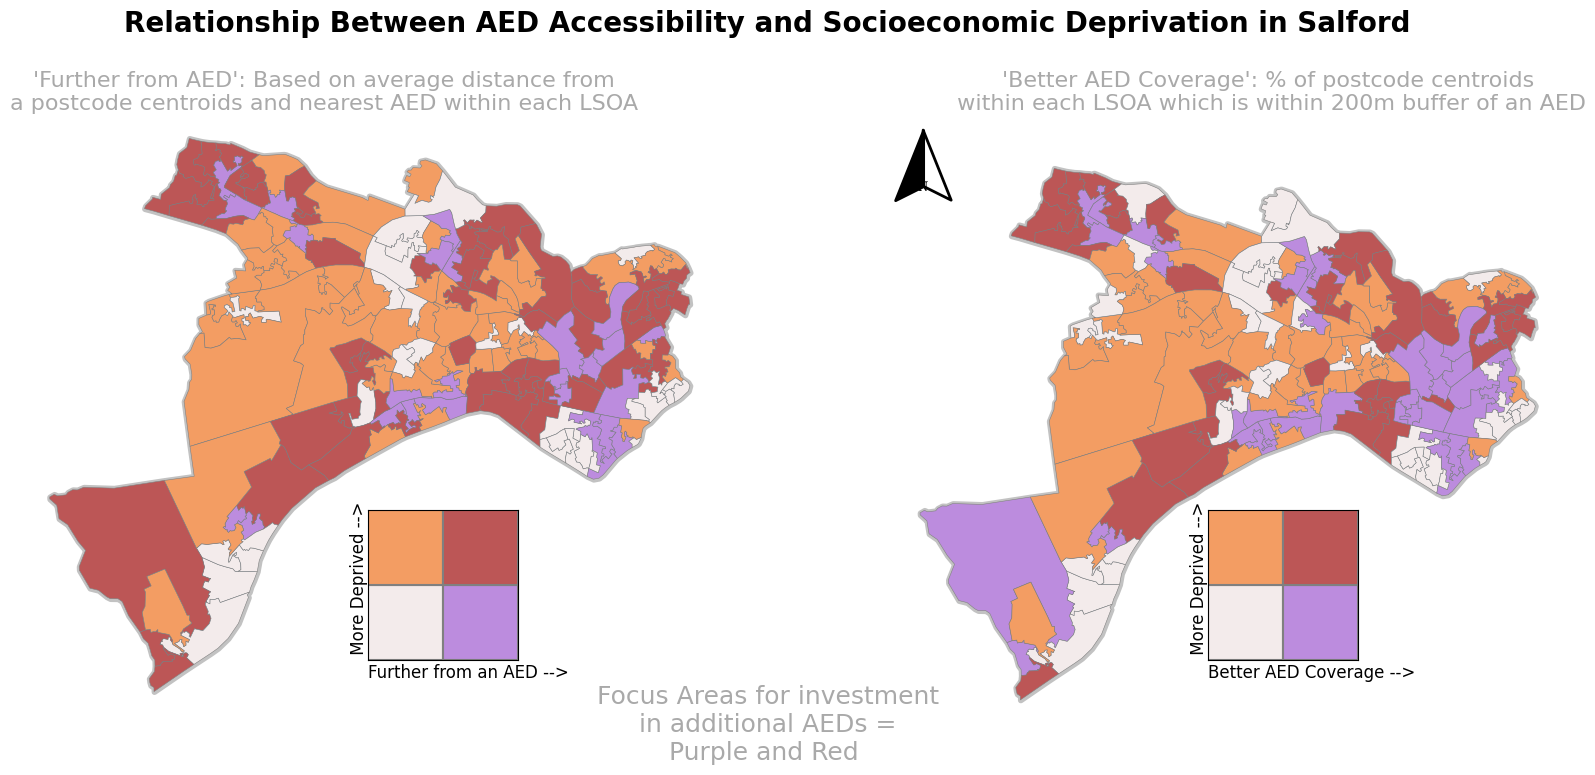

In [119]:
from matplotlib.patches import Rectangle
## Bivariate plot methodology adapted (https://schoolofcities.github.io/urban-data-storytelling/urban-data-visualization/bivariate-choropleth-maps/bivariate-choropleth-maps.html#bivariate-colours)

fig, axes = plt.subplots(1, 2, figsize=(20, 10)) # two columns one row
ax0, ax1 = axes

# Create colours for bivaraite matrix
color_mapping = {
    "0-1": "#bc8cde",
    "0-0": "#f3ebeb",
    "1-1": "#bc5656",
    "1-0": "#f39d63"
}

##Create Values to combine the two variables ( deprivation and AED Access ) for a bivarate structured plot - like an overlaid chropleth.
# create two bins which splits the LSOAs by average distance results in values of 0 and 1.
Joined_data["x_group"] = (Joined_data["Average_Distance"] >= 200).astype(int) # Use 200m buffer threshold to split as average distance above or below threshold.


# create two bins (k)  which splits the LSOAs by IMD Rank  results in values of 0 and 1.
# Subtract from 1 as want scale on axis to go from less to more deprived which would be higher IMD rank to lower IMD rank
Joined_data["y_group"] = 1-(Joined_data[["Salford_IMDRank"]].apply(mapclassify.Quantiles.make(rolling=True,k=2)))

#Create a string concating the two values to asign to one of the four quandrants on the bivariate matrix
Joined_data["xy_group"] = Joined_data["x_group"].astype(str) + "-" + Joined_data["y_group"].astype(str)



# Salford border around figures
Salford_outline.plot(
    edgecolor = "#c2c2c2",
    linewidth = 4.2,
    ax = ax0
);

# Create bivariate Choropleth using concated values
Joined_data.plot(
    column = "xy_group",
    categorical = True,
    edgecolor = "gray",
    linewidth = 0.4,
    ax = ax0, #1st column
    color=Joined_data["xy_group"].map(color_mapping), # use key to map
).set_axis_off();

##Custom Legend ##

#Prompt: Help write a Python script that generates a custom 2×2 bivariate legend using matplotlib.
#The legend should be built using Rectangle patches, and the four squares should be created by looping through my color_mapping dictionary with keys '0-0', '0-1', '1-0', '1-1'.
#Each key should map to a position in the 2×2 grid.
#Include axis annotations showing direction arrows (e.g., ‘Further from an AED ->’ and ‘More Deprived ->’).

# Build 2×2 matrix from color_mapping
bivariate_colors = [
    [color_mapping["0-0"], color_mapping["0-1"]],
    [color_mapping["1-0"], color_mapping["1-1"]],
]

# Add legend axis
legend_ax0 = fig.add_axes([0.30, 0.25, 0.075, 0.15]) # Position of legend 0,0 point
legend_ax0.set_xticks([])
legend_ax0.set_yticks([])
legend_ax0.set_frame_on(True) # neat line around matrix

# Draw squares for legend matrix
for i in range(2):
    for j in range(2):
        legend_ax0.add_patch(
            Rectangle(
                (j/2, i/2), # 2x2 format
                0.5, # square to fill 50% of the axis width
                0.5, # square to fill 50% of the axis height
                facecolor=bivariate_colors[i][j], #
                edgecolor="gray",
                linewidth=1.5
            )
        )


# Annotations on legend

# x-axis
legend_ax0.annotate(
    "Further from an AED -->",
    xy=(0, -0.12), # position 0.12 below of the x axis and align with the start of y axis (O)
    xycoords="axes fraction",
    fontsize=12,
    ha="left"
)

# y-axis
legend_ax0.annotate(
    " More Deprived -->",
    xy=(-0.12, 0), # position 0.12 to the left of the y axis and align with the start of x axis (O)
    xycoords="axes fraction",
    fontsize=12,
    rotation=90, # write vertically
    va="bottom")



### 2nd Plot  - Repeat above for ax1 with different x_group variable ###

# create two bins (k) which splits the LSOAs by % of LSOA postcode centroids within 200m of AED, results in values of 0 and 1.
# Subtract from 1 as want scale on axis to go from higher coverage to lower coverage  which would be higher % to lower %
Joined_data["x_group"] = 1-Joined_data[["Covered"]].apply(mapclassify.Quantiles.make(rolling=True,k=2))

# create two bins (k) which splits the LSOAs by IMD Rank  results in values of 0 and 1.
# Subtract from 1 as want scale on axis to go from less to more deprived which would be higher IMD rank to lower IMD rank
Joined_data["y_group"] = 1-(Joined_data[["Salford_IMDRank"]].apply(mapclassify.Quantiles.make(rolling=True,k=2)))

#Create a string concating the two values to asign to one of the four quandrants on the bivariate matrix
Joined_data["xy_group"] = Joined_data["x_group"].astype(str) + "-" + Joined_data["y_group"].astype(str)


# Salford border
Salford_outline.plot(
    edgecolor = "#c2c2c2",
    linewidth = 4.2,
    ax = ax1
);

# Create bivariate Choropleth using concated values
Joined_data.plot(
    column = "xy_group", # fill colour
    categorical = True,
    edgecolor = "gray",
    linewidth = 0.4,
    ax = ax1,
    color=Joined_data["xy_group"].map(color_mapping),
).set_axis_off();


# Build 2×2 matrix from color_mapping
bivariate_colors = [
    [color_mapping["0-0"], color_mapping["0-1"]],
    [color_mapping["1-0"], color_mapping["1-1"]],
]

# Add legend axis
legend_ax1 = fig.add_axes([0.72, 0.25, 0.075, 0.15]) # Position of legend 0,0 point
legend_ax0.set_xticks([])
legend_ax1.set_xticks([])
legend_ax1.set_yticks([])
legend_ax1.set_frame_on(True) # neat line around matrix

# Draw squares for legend matrix
for i in range(2):
    for j in range(2):
        legend_ax1.add_patch(
            Rectangle(
                (j/2, i/2), # 2x2 format
                0.5, # square to fill 50% of the axis width
                0.5, # square to fill 50% of the axis height
                facecolor=bivariate_colors[i][j],
                edgecolor="gray",
                linewidth=1.5,
                  )
        )

# Annotations on legend

# x-axis

legend_ax1.annotate(
    "Better AED Coverage -->",
    xy=(0, -0.12),# position 0.12 to the left of the y axis and align with the start of x axis (O)
    xycoords="axes fraction",
    fontsize=12,
    ha="left"
)

# y-axis
legend_ax1.annotate(
    " More Deprived -->",
    xy=(-0.12, 0), # position 0.12 to the left of the y axis and align with the start of x axis (O)
    xycoords="axes fraction",
    fontsize=12,
    rotation=90, # write text vertically
    va="bottom")

# Add a North arrow (https://github.com/pmdscully/geo_northarrow)

# Define plot to add to
axarrow = ax1
# Add north arrow
add_north_arrow(
    axarrow,scale=1, xlim_pos=0.05,ylim_pos=0.9,color="#000") # choose position within plot

fig.suptitle("Relationship Between AED Accessibility and Socioeconomic Deprivation in Salford", fontsize=20, fontweight='bold', y=0.9) # Main title
fig.text(0.5, 0.15,"Focus Areas for investment\n in additional AEDs = \nPurple and Red ", fontsize=18,color='darkgray', ha='center') #Text at bottom of figure
fig.text(0.28, 0.80, "'Further from AED': Based on average distance from \na postcode centroids and nearest AED within each LSOA ", ha='center', fontsize=16, color='darkgray') # Specify position on the plot so that over the first
fig.text(0.75, 0.80, "'Better AED Coverage': % of postcode centroids\n within each LSOA which is within 200m buffer of an AED", ha='center', fontsize=16, color='darkgray') # Specify position on plot so that over 2nd
;

This plot was chosen to show the alternative aspect of ‘availability’, rather than repeating the metrics calculated. It is important for policy makers to consider both aspects as there is no benefit to having an AED within 200m if you cannot access it at night.

The left plot compares AED availability.  An increased proportion of 24/7 suggests better access. The right plot compares access type, and whether AED are publicly available or restricted, potentially in a private business or home. Higher public access increase accessibility.

It could be suggested that in more deprived areas there is increased accessibility through public AED, however it could be that they have restricted access. Whereas, within the less deprived where there is increased restricted AEDs, these may be more accessible to people as they may still be 24/7 but only available to a small group of people.

This could not be used with national IMD rankings as the uneven number of LSOAs in each decile would result in any patterns being dominated by the majority the deciles with larger numbers of AEDs rather than the comparison of accessibility by time, day and security.


# **Discussion**

**Data:**

The source which the defibrillator data originates is a system which is voluntary to register AEDs which risks an incomplete dataset which could result in inaccurate conclusions. For example, an LSOA which appears to have low accessibility, may just not have the AEDs within the area recorded. The output from the analysis could identify locations for improved education requirements on registering AEDs, which then in turn could increase usage as the location is public knowledge.

IMD has been used to investigate the relationship between AED accessibility and deprivation, however, there has been no strong conclusion reached. Further studies could analysis the individual components that make up the composite IMD index, as some may influence more than others.


**Methodology:**

The use of Euclidean distance is a limitation. In real life, this would not be an accurate measure of the distance required to travel to reach an AED as people cannot travel due the layout of roads and other topographical barriers. Integration of the road network would improve the robustness of these measurements, as used by Burgoine et al (2023).

 The initial method calculating the percentage of LSOA area which intersected with the buffer was discarded as whilst LSOA have consistent populations, they are not equal in area and would favour the smaller LSOAs as having better coverage. The method adopted uses the centroid of postcodes, improving the granularity (n=12544) and then aggregated.

The raw count of AED per LSOA was not used as it does not imply accessibility, as people can use AEDs in adjacent LSOAs, and their closest may be one located across the boundary.  Similarly, calculating the nearest AED to postcode distance does not account for AEDs which are in the LSOAs within other local authorities that border Salford. There may be one closer that is excluded from the analysis. Inclusion of bordering LSOA’s from other local authorities in the AED dataset but exclude the LSOA’s from the analysis themselves could be explored. Alternatively, minimise this effect my analysing a larger area.


**Reproducibility:**

 The data required to reproduce this analysis is available within the GitHub repository along with a readme document which includes a data dictionary.
The two categorisation scales of deprivation allow this analysis to be applied at both national and local scale. The analysis can be replicated with new data, such as a subset of another local authority, or larger scale of country or country. To improve replicability, data frames and derived column names such as ‘Salford_Defibs’ or ‘Salford_IMDRank’ should be made interoperable by being called ‘AOI_IMDRank’, which could then be assigned to any area without having to manually change values in the code, reducing human error.


# **References**

•	Allen, J., Greenberg, J., St-Louis, E., Zhang, M., Kali, A. and Chapple, K. (2025). Urban Data Analytics, Visualization, and Storytelling. [online] Zenodo (CERN European Organization for Nuclear Research). European Organization for Nuclear Research. doi:10.5281/zenodo.17912387.

•	Burgoine, T., Austin, D., Wu, J., Quinn, T., Shurmer, P., Gale, C.P. and Wilkinson, C. (2023). Automated external defibrillator location and socioeconomic deprivation in Great Britain. Heart, [online] 110(3), pp.heartjnl-2023–322985. doi:10.1136/heartjnl-2023-322985.

•	Colblindor (2016). Coblis — Color Blindness Simulator – Colblindor. [online] Color-blindness.com. Available at: https://www.color-blindness.com/coblis-color-blindness-simulator/.

•	Defibrillator data. (no date). [online] British Heart Foundation. Available at: https://www.bhf.org.uk/defibdata [Accessed 23 July 2026].

•	GeoPandas 0.7.0 — GeoPandas 0.7.0 documentation. (n.d.). [online] geopandas.org. Available at: https://geopandas.org/ [Accessed 23 July 2026].

•	Github.io. (2017). Bivariate Color Palette Generator. [online] Available at: https://jakobzhao.github.io/storymap/assets/color.html [Accessed 23 July 2026].

•	Indices of Deprivation 2025 Data. (2025). [online] Communities.gov.uk. Available at: https://deprivation.communities.gov.uk/ [Accessed 23 July 2026].

•	 Lower layer Super Output Areas (December 2021) Boundaries EW BGC (V5). (2021). [online] Statistics.gov.uk. Available at:https://geoportal.statistics.gov.uk/datasets/68515293204e43ca8ab56fa13ae8a547_0/explore?location=52.837634%2C-2.489483%2C7 [Accessed 23 July 2026].

•	matplotlib.patches — Matplotlib 3.6.0 documentation. (n.d.). [online] matplotlib.org. Available at: https://matplotlib.org/stable/api/patches_api.html [Accessed 23 July 2026].


•	matplotlib.patches.Rectangle — Matplotlib 3.8.4 documentation. (n.d.). [online] matplotlib.org. Available at: https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html#matplotlib.patches.Rectangle [Accessed 23 July 2026].

•	National Defibrillator Network - The Circuit (2021). National Defibrillator Network - The Circuit. [online] British Heart Foundation. Available at: https://www.bhf.org.uk/how-you-can-help/how-to-save-a-life/defibrillators/national-defibrillator-network-the-circuit [Accessed 18 July 2026].


•	Noble, S., Mclennan, D., Noble, M., Plunkett, E., Leach, K., Mason, B., Wright, G., Barnes, H., Gasior, K. and Penney, B. (n.d.). October 2025 Ministry of Housing, Communities & Local Government The English Indices of Deprivation 2025 Research report. [online] Available at: https://assets.publishing.service.gov.uk/media/68ff547a49d08dd781b48351/ID_2025_Research_Report.pdf [Accessed 23 July 2026].


•	numpy.log1p — NumPy v1.26 Manual. (n.d.). [online] numpy.org. Available at: https://numpy.org/doc/stable/reference/generated/numpy.log1p.html [Accessed 23 July 2026].

•	pandas: powerful Python data analysis toolkit — pandas 0.25.3 documentation. (2019). [online] Pydata.org. Available at: https://pandas.pydata.org/pandas-docs/stable/index.html [Accessed 23 July 2026].

•	Perkins, G. D, Lockey, A.S., de Belder, M.A., Moore, F., Weissberg, P. and Gray, H. (2015). National initiatives to improve outcomes from out-of-hospital cardiac arrest in England. Emergency Medicine Journal, [online] 33(7), pp.448–451. doi:10.1136/emermed-2015-204847.


•	Public Health Technical Guidance – Assigning deprivation categories. (2015). [online] Phe.org.uk. Available at: https://fingertips.phe.org.uk/static-reports/public-health-technical-guidance/IMD/Assigning_deprivation_categories.html [Accessed 22 July 2026].


•	seaborn.pydata.org. (n.d.). API reference — seaborn 0.11.2 documentation. [online] Available at: https://seaborn.pydata.org/api.html.

•	Shapely — Shapely 2.1.2 documentation. (2025). [online] Readthedocs.io. Available at: https://shapely.readthedocs.io/en/stable/index.html [Accessed 23 July 2026].


•	Statistics.gov.uk. (2026). ONSPD Online latest Postcode Centroids. [online] Available at: https://geoportal.statistics.gov.uk/datasets/84787e80aca04bb388caad29f89946b0_0/explore?location=53.486210%2c-2.229295%2c10 [Accessed 23 July 2026].
